# Intro a Scikit Learn

La librería `scikit-learn` es una de las librerías más populares para Machine Learning en Python. Esta librería es muy completa y tiene una gran cantidad de algoritmos de Machine Learning implementados, así como herramientas para preprocesamiento de datos, evaluación de modelos, etc.

![scikit-learn](https://hkalabs.com/wp-content/uploads/2018/07/scikitLearn-2.png)

## 1. Instalación

De nuevo, usamos `pip` para instalar la librería:

```bash
pip install scikit-learn==<version>
```

⚠️ fíjate que la importación de la librería es `sklearn` y no `scikit-learn`.

In [1]:
import sklearn

## 2. Cargar los datos

Cómo hemos visto anteriormente, este paso lo cubriremos haciendo uso de la librería `pandas`. Podemos traernos los datos desde una BBDD, un archivo CSV, etc. Para este ejemplo, vamos a usar el dataset de titanic que ya hemos visto en la clase anterior.

In [2]:
import pandas as pd

CSV_PATH = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(CSV_PATH)
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3. Exploración de los datos

En este paso, vamos a hacer un análisis exploratorio de los datos. Vamos a ver si hay valores nulos, vamos a ver la distribución de las variables, etc.

### 3.1 Correlación entre variables

Una de las cosas que podemos hacer es ver la correlación entre las variables. Esto nos puede dar una idea de qué variables están más relacionadas entre sí. La correlación es un valor entre -1 y 1. Si es 1, significa que las variables aumentan juntas. Si es -1, significa que una variable disminuye cuando la otra aumenta. Si es 0, significa que no hay relación entre las variables.

Text(0.5, 1.0, 'Titanic Numeric Variables Correlation')

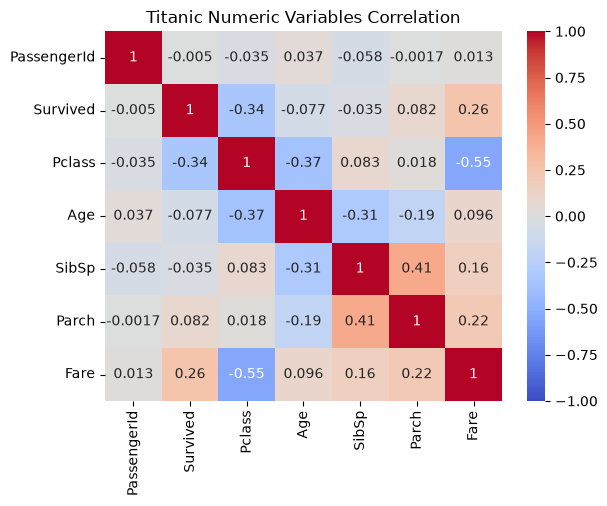

In [4]:
import seaborn as sns


titanic_correlation = titanic_df.corr(numeric_only=True)  #Las variables categoricas no se puede hacer correlacion
ax = sns.heatmap(
    titanic_correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
)
ax.set_title('Titanic Numeric Variables Correlation')

### 3.2 Ratio de Supervivencia

Vamos a ver qué ratio de supervivencia existe en función a algunas variables. Por ejemplo, de la edad o el sexo.

Text(0.5, 1.0, 'Survival distribution by Age')

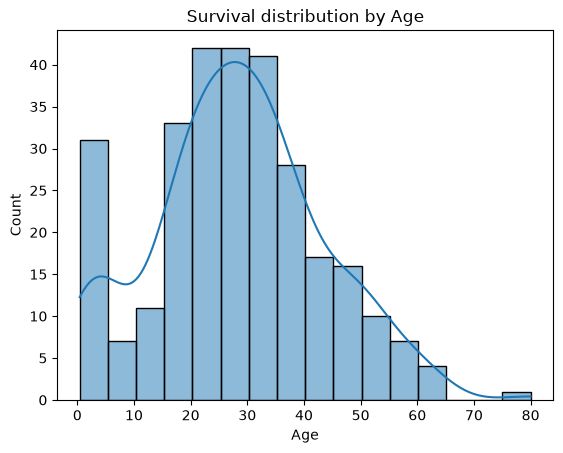

In [5]:
survived_filter = titanic_df['Survived'] == 1
survived_age = titanic_df[survived_filter]["Age"]
ax = sns.histplot(survived_age, kde=True)
ax.set_title('Survival distribution by Age')


Text(0.5, 1.0, 'Survival rate by Sex')

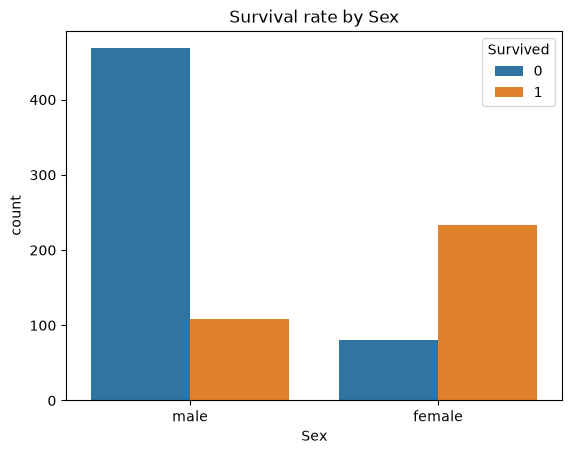

In [6]:
ax = sns.countplot(titanic_df, x="Sex", hue="Survived")
ax.set_title('Survival rate by Sex')

## 3. Preprocesamiento de datos

En este paso, vamos a hacer un preprocesamiento de los datos. Esto puede incluir la eliminación de valores nulos, la codificación de variables categóricas, la normalización de los datos, etc.

### 3.1 Eliminar valores innecesarios

Recuerdalo siempre: la calidad de tu modelo nunca será mejor que la calidad de tus datos. Por tanto, es muy importante preprocesar los datos antes de entrenar un modelo. Imaginemos que tras hacer un análisis exploratorio de los datos, hemos visto que hay variables que no aportan información relevante. En este caso, podemos eliminarlas. Por simplificar el ejemplo, vamos a eliminar las columnas `PassengerId`, `Name`, `Ticket`, `Cabin`, `Fare`, `Parch`  (número de padres/hijos a bordo) y `SibSp` (número de hermanos/cónyuges a bordo).

In [7]:
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Parch', 'SibSp', 'Fare'], axis=1)
titanic_df.head()

,Survived,Pclass,Sex,Age,Embarked
0,0,3,male,22.0,S
1,1,1,female,38.0,C
2,1,3,female,26.0,S
3,1,1,female,35.0,S
4,0,3,male,35.0,S


### 3.2 Eliminar valores nulos

Vamos a ver primero qué campos tienen valores nulos

In [8]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   Embarked  889 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 34.9+ KB


Vemos que todos los campos están completos salvo para `Age`.

In [9]:
mean_age = titanic_df["Age"].mean()
display(mean_age)
titanic_df["Age"] = titanic_df["Age"].fillna(mean_age)

29.69911764705882

In [10]:
embarked_mode = titanic_df["Embarked"].mode()[0]  # mode() returns a Series. Es la moda. Se pone el 0 para asegurarte de que tome el primer valor
display(embarked_mode)
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(embarked_mode)

'S'

### 3.3 Convertir variables categóricas a numéricas

En este caso, vamos a convertir las variables categóricas (tipo `object`) a numéricas (tipo `int`). `scikit-learn` tiene una serie de herramientas para preprocesar los datos, como por ejemplo `LabelEncoder`, para codificar etiquetas.

In [11]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
label_encoder.fit(["paris", "paris", "tokyo", "amsterdam"])

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[<U9](3,)","['amsterdam','paris','tokyo']"


Ahora podemos convertir las variables categóricas a numéricas.

In [12]:
label_encoder.transform(["tokyo", "tokyo", "paris"])

array([2, 2, 1])

Y a la inversa, de numéricas a categóricas, también

In [13]:
label_encoder.inverse_transform([2, 2, 1, 0])

array(['tokyo', 'tokyo', 'paris', 'amsterdam'], dtype='<U9')

Procedemos a convertir la variable `Sex` a numérica. Usamos `fit_transform` para ajustar el codificador y transformar la variable al mismo tiempo.

In [14]:
label_encoder_sex = LabelEncoder()
display(titanic_df['Sex'])
titanic_df["Sex"] = label_encoder_sex.fit_transform(titanic_df["Sex"])
display(titanic_df['Sex'])
titanic_df.head()

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int32

,Survived,Pclass,Sex,Age,Embarked
0,0,3,1,22.0,S
1,1,1,0,38.0,C
2,1,3,0,26.0,S
3,1,1,0,35.0,S
4,0,3,1,35.0,S


In [15]:
label_encoder_embarked = LabelEncoder()
titanic_df["Embarked"] = label_encoder_embarked.fit_transform(titanic_df["Embarked"])
display(label_encoder_embarked.inverse_transform([0,1,2]))
titanic_df.head()

array(['C', 'Q', 'S'], dtype=object)

,Survived,Pclass,Sex,Age,Embarked
0,0,3,1,22.0,2
1,1,1,0,38.0,0
2,1,3,0,26.0,2
3,1,1,0,35.0,2
4,0,3,1,35.0,2


### 3.4 Normalización de los datos

La normalización de los datos es un paso importante en el preprocesamiento de los datos. La normalización de los datos es el proceso de **escalar los datos a un rango fijo**. Hay diferentes técnicas para normalizar los datos, como por ejemplo la normalización `MinMax`, consistente en escalar los datos al rango [0, 1]. `scikit-learn` tiene una clase llamada `MinMaxScaler` que nos permite hacer esto.

Hacemos lo mismo con la edad.

In [16]:
from sklearn.preprocessing import MinMaxScaler

display(titanic_df['Age'])
min_max_scaler_age = MinMaxScaler()
titanic_df["Age"] = min_max_scaler_age.fit_transform(titanic_df[["Age"]])
display(titanic_df['Age'])
titanic_df.head()

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

0      0.271174
1      0.472229
2      0.321438
3      0.434531
4      0.434531
         ...   
886    0.334004
887    0.233476
888    0.367921
889    0.321438
890    0.396833
Name: Age, Length: 891, dtype: float64

,Survived,Pclass,Sex,Age,Embarked
0,0,3,1,0.271174,2
1,1,1,0,0.472229,0
2,1,3,0,0.321438,2
3,1,1,0,0.434531,2
4,0,3,1,0.434531,2


## 4. Dividir los datos en entrenamiento y test

La división de los datos en entrenamiento y test es un paso importante en Machine Learning. La idea es entrenar el modelo con una parte de los datos y evaluarlo con otra parte. `scikit-learn` tiene una función llamada `train_test_split` que nos permite hacer esto.

Primero, debemos separar la variable dependiente, también conocida como variable objetivo, de las variables independientes. Las variables independientes son aquellas que se utilizan para predecir la variable dependiente. En este caso, la variable dependiente es `Survived` y las variables independientes son el resto de variables.

In [17]:
from sklearn.model_selection import train_test_split


TEST_SIZE = 0.2
RANDOM_STATE = 42    
# El random state es una especie de semilla para que a la hora de generar numeros aleatorios, todos sepamos cuales sean esos numeros aleatorios. Como lo de la semilla en los vientos aerolasticos. Es aleatorio pero sabemos que aleatoriedad es. El 42 es por lo de la guia del autoestopista
# Esto sirve para decidir que conjunto de valores van para entrenamiento y cuantos para test

X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [18]:
display(X_train)
display(X_test)
display(y_train)
display(y_test)

,Pclass,Sex,Age,Embarked
331,1,1,0.566474,2
733,2,1,0.283740,2
382,3,1,0.396833,2
704,3,1,0.321438,2
813,3,0,0.070118,2
...,...,...,...,...
106,3,0,0.258608,2
270,1,1,0.367921,2
860,3,1,0.509927,2
435,1,0,0.170646,2


,Pclass,Sex,Age,Embarked
709,3,1,0.367921,0
439,2,1,0.384267,2
840,3,1,0.246042,2
720,2,0,0.070118,2
39,3,0,0.170646,0
...,...,...,...,...
433,3,1,0.208344,2
773,3,1,0.367921,0
25,3,0,0.472229,2
84,2,0,0.208344,2


331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

## 5. Entrenar el modelo

La primera pregunta que debemos hacernos es: ¿qué algoritmo de Machine Learning vamos a usar? En este caso, nuestro objetivo es predecir si un pasajero del Titanic sobrevivió o no. **Este es un problema de clasificación binaria**, por lo que podemos **usar algoritmos de clasificación** como la Regresión Logística, Árboles de Decisión, Random Forest, etc. En este caso, **vamos a usar la Regresión Logística** que `scikit-learn` tiene implementada en la clase `LogisticRegression`.

In [19]:
from sklearn.linear_model import LogisticRegression

# Create an instance of LogisticRegression
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 6. Evaluar el modelo

Una vez que hemos entrenado el modelo, es necesario evaluarlo. De nuevo es importante saber ante qué problema nos enfrentamos. Si se trata de un modelo de clasificación usaremos las siguientes métricas:

- **Accuracy**: es el número de predicciones correctas dividido por el número total de predicciones.
- **Precission**: es el número de predicciones correctas dividido por el número de predicciones correctas y el número de falsos positivos.
- **Recall**: es el número de predicciones correctas dividido por el número de predicciones correctas y el número de falsos negativos.
- **F1 Score**: es la media armónica de la precisión y el recall.

Si se tratara de un modelo de regresión, usaríamos otras métricas como:

- **Mean Absolute Error (MAE)**: es la media del valor absoluto de los errores.
- **Mean Squared Error (MSE)**: es la media de los errores al cuadrado.
- **Root Mean Squared Error (RMSE)**: es la raíz cuadrada de la media de los errores al cuadrado.


In [20]:
# Para entender estas metricas tienes https://matesanz.github.io/python-machine-learning-course/%F0%9F%93%9A-Tutorials/%F0%9F%93%89-Scikit-Learn/scikit-learn-evaluation/

from sklearn import metrics

# Predict the labels of the test set
y_pred = model.predict(X_test)

accuracy=metrics.accuracy_score(y_test, y_pred)
precision=metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
F1_score = metrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_Score: {F1_score}")

# Compute the accuracy of the model
report = metrics.classification_report(y_test, y_pred)
print(report)

Accuracy: 0.7988826815642458
Precision: 0.7567567567567568
Recall: 0.7567567567567568
F1_Score: 0.7567567567567568
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 7. Inferencia

Una vez que hemos entrenado y evaluado el modelo, podemos hacer inferencias con él. Es decir, podemos hacer predicciones con datos nuevos. Para hacer predicciones con un modelo de `scikit-learn`, usamos el método `predict`.

In [21]:
my_data = X_test.iloc[0].values
display(my_data)
my_data.shape

array([3.        , 1.        , 0.36792055, 0.        ])

(4,)

⚠️ **Importante**: la entrada de datos debe tener el mismo `shape` que los datos de entrenamiento. Es decir, debe tener 2 dimensiones (filas y columnas) y el mismo número de columnas que los datos de entrenamiento.

In [22]:
my_data_batch = my_data.reshape(1, -1)  # Reshape the data to a 2D array
display(my_data_batch)
my_data_batch.shape

array([[3.        , 1.        , 0.36792055, 0.        ]])

(1, 4)

Finalmente debemos convertirlo a un `DataFrame` de `pandas` con una sola fila ya que ese fue el formato de entrada que usamos para entrenar el modelo.

In [23]:
my_data_batch_df = pd.DataFrame(my_data_batch, columns=X_test.columns)
display(my_data_batch_df)

,Pclass,Sex,Age,Embarked
0,3.0,1.0,0.367921,0.0


Ahora sí, realizamos la predicción.

In [24]:
model.predict(my_data_batch_df)  # 0: Not survived, 1: Survived

array([0], dtype=int64)

## Ejercicio: ¿Sobreviviría? 🤔

Ahora que ya hemos entrenado nuestro modelo, podemos usarlo para predecir si un pasajero del Titanic sobreviviría o no. Para ello, vamos a introducir nuestros propios datos a día de hoy. Para campos como el `Fare`, `Pclass` o `Embarked` podemos usar los valores que consideremos (como la media, la moda, etc.). Para el resto de campos, podemos introducir valores reales.

In [25]:
AGE = 30
PCLASS = 2.0
EMBARKED = "S"
SEX = "male"

In [26]:
age_scaled = min_max_scaler_age.transform([[AGE]])[0,0]
age_scaled

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


0.37170143252073384

In [27]:
embarked_label = label_encoder_embarked.transform([EMBARKED])[0]
embarked_label

2

In [28]:
sex_label = label_encoder_sex.transform([SEX])[0]
sex_label

1

In [29]:
import numpy as np

my_data=np.array([PCLASS, sex_label, age_scaled, embarked_label]).reshape(1,-1)
my_data

array([[2.        , 1.        , 0.37170143, 2.        ]])

In [30]:
display(model.predict(my_data))
display(model.predict_proba(my_data))

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.79208435, 0.20791565]])


- ¿Sobreviviría si hubiera ido en primera clase?

¿Y si fuera del sexo opuesto?

¿Y si fuera un niño/a?

¿Cuál sería la probabilidad de supervivencia? 💡 los modelos tienen un método `predict_proba` que nos devuelve la probabilidad de cada clase

In [31]:
AGE = 12
PCLASS = 1.0
EMBARKED = "S"
SEX = "female"

In [32]:
age_scaled = min_max_scaler_age.transform([[AGE]])[0,0]
embarked_label = label_encoder_embarked.transform([EMBARKED])[0]
sex_label = label_encoder_sex.transform([SEX])[0]

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [33]:
import numpy as np

my_data=np.array([PCLASS, sex_label, age_scaled, embarked_label]).reshape(1,-1)
my_data

array([[1.        , 0.        , 0.14551395, 2.        ]])

In [34]:
display(model.predict(my_data))
display(model.predict_proba(my_data))

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.08225456, 0.91774544]])

## Bonus: Mejora la precisión del modelo 🚀

Por simplificar, hemos dejado atrás algunas características que podrían mejorar la precisión del modelo. Por ejemplo, hemos eliminado algunas columnas que podrían ser útiles. Además, hemos rellenado los valores nulos con la media o la moda, pero podríamos haber usado otros métodos. Por último, hemos usado la Regresión Logística, pero podríamos haber usado otros algoritmos de clasificación. ¿Te atreves a mejorar la precisión del modelo? 💪

In [35]:
titanic_df = pd.read_csv(CSV_PATH)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
training_dataset = titanic_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
training_dataset.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [37]:
training_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


### Rellenamos la edad diferenciando por el sexo

In [38]:
# female_age = training_dataset[training_dataset['Sex']=='female']
# avg_female_age = female_age['Age'].mean()
# male_age = training_dataset[training_dataset['Sex']=='male']
# avg_male_age = male_age['Age'].mean()
# display(avg_female_age, avg_male_age)

# training_dataset['Age'] = np.where(training_dataset['Age'].isnull() & (training_dataset['Sex']=='female'), avg_female_age, training_dataset['Age'])
# training_dataset['Age'] = np.where(training_dataset['Age'].isnull() & (training_dataset['Sex']=='male'), avg_male_age, training_dataset['Age'])

#* Se puede hacer de forma mas eficiente asi
training_dataset['Age'] = (
    training_dataset['Age'].fillna(
        training_dataset.groupby('Sex')['Age'].transform('mean')))


label_encoder_sex = LabelEncoder()
display(training_dataset['Sex'])
training_dataset["Sex"] = label_encoder_sex.fit_transform(training_dataset["Sex"])
display(training_dataset['Sex'])
display(training_dataset.head())
training_dataset.info()

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int32

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,NaN,S
1,1,1,0,38.0,1,0,71.2833,C85,C
2,1,3,0,26.0,0,0,7.9250,NaN,S
3,1,1,0,35.0,1,0,53.1000,C123,S
4,0,3,1,35.0,0,0,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int32(1), int64(4), object(2)
memory usage: 59.3+ KB


In [39]:
embarked_mode = training_dataset["Embarked"].mode()[0]  # mode() returns a Series. Es la moda. Se pone el 0 para asegurarte de que tome el primer valor
display(embarked_mode)
training_dataset["Embarked"] = training_dataset["Embarked"].fillna(embarked_mode)

label_encoder_embarked = LabelEncoder()
training_dataset["Embarked"] = label_encoder_embarked.fit_transform(training_dataset["Embarked"])
display(label_encoder_embarked.inverse_transform([0,1,2]))
training_dataset.head()

'S'

array(['C', 'Q', 'S'], dtype=object)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,NaN,2
1,1,1,0,38.0,1,0,71.2833,C85,0
2,1,3,0,26.0,0,0,7.9250,NaN,2
3,1,1,0,35.0,1,0,53.1000,C123,2
4,0,3,1,35.0,0,0,8.0500,NaN,2


In [40]:
#* Rellenamos los NaN del cabin con 0 y si tiene cabina con un 1
import numpy as np

training_dataset['Cabin'] = np.where(training_dataset['Cabin'].isna(), 0, 1)

display(training_dataset['Cabin'].sum())




204

In [41]:
training_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    int32  
 8   Embarked  891 non-null    int32  
dtypes: float64(2), int32(3), int64(4)
memory usage: 52.3 KB


In [42]:
from sklearn.model_selection import train_test_split


TEST_SIZE = 0.2
RANDOM_STATE = 33    
# El random state es una especie de semilla para que a la hora de generar numeros aleatorios, todos sepamos cuales sean esos numeros aleatorios. Como lo de la semilla en los vientos aerolasticos. Es aleatorio pero sabemos que aleatoriedad es. El 42 es por lo de la guia del autoestopista
# Esto sirve para decidir que conjunto de valores van para entrenamiento y cuantos para test

X = training_dataset.drop("Survived", axis=1)
y = training_dataset["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [43]:
from sklearn.linear_model import LogisticRegression

# Create an instance of LogisticRegression
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

c:\Users\Adrian\anaconda3\envs\DS_training\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [44]:
from sklearn import metrics

# Predict the labels of the test set
y_pred = model.predict(X_test)

accuracy=metrics.accuracy_score(y_test, y_pred)
precision=metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
F1_score = metrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_Score: {F1_score}")

# Compute the accuracy of the model
report = metrics.classification_report(y_test, y_pred)
print(report)

Accuracy: 0.8156424581005587
Precision: 0.8095238095238095
Recall: 0.7083333333333334
F1_Score: 0.7555555555555555
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       107
           1       0.81      0.71      0.76        72

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

